In [19]:
# Debugging Survey Data Read

import os
import pandas as pd
import numpy as np
import xlrd

print("-------------------- LOADING SURVEY DATA --------------------------------")


def parse_year(year_val):
    """Convert year string like '2022S', '2022A', '2022W' to numeric year."""
    # print("Year val is " + str(year_val) + " and its type is " + str(type(year_val)))
    if isinstance(year_val, str):
        if year_val.endswith("S"):
            return int(year_val[:-1]) - 0.5
        elif year_val.endswith(("A", "W")):
            return int(year_val[:-1])
        else:
            return int(year_val)  # just in case it's string but plain year
    return int(year_val)  # if it's already an int


# Set up paths
folder_path = "EU_dataset"
file_title = "Cleaned_Parlemeter_Data-LeftRight"
file_name = file_title + ".xlsx"
survey_file = os.path.join(folder_path, file_name)
sheets = pd.ExcelFile(survey_file, engine='openpyxl').sheet_names[1:]  # Skip 'RowHeaders'

survey_data = []

for sheet in sheets:
    # print(sheet)
    country = sheet.split("-")[0]  # Extract country code (e.g., "BE")
    df_sheet = pd.read_excel(survey_file, sheet_name=sheet, header=None, engine='openpyxl')

    # Years are in the first row
    years = df_sheet.iloc[0, :].tolist()
    # print(years)

    # Extract counts for positions 1-10 (skip % rows and DK/Refusal)
    counts_matrix = []
    for i in range(10):  # Positions 1-10
        row_index = 2 + 2 * i  # Count rows are at indices 1,3,5,...,19
        counts_matrix.append(df_sheet.iloc[row_index, :].tolist())

    # Process each year
    for j, year in enumerate(years):
        # print(f"Current year parsing: {year}")
        year_num = parse_year(year)  # use parsed numeric year
        # print(f" Count is: {float(counts_matrix[i][j])}")
        counts = [float(counts_matrix[i][j]) for i in range(10)]
        
        total_valid = sum(counts)
        distribution = [c / total_valid for c in counts]
        pooled_counts = counts[:4] + [counts[4] + counts[5]] + counts[6:]
        pooled_distribution = [c / total_valid for c in pooled_counts]

        survey_data.append({
            "country": country,
            "year": year_num,
            "counts": counts,
            "binned_distribution": distribution,
            "binned_distribution_5_6clubbed": pooled_distribution,
            "total_respondents": total_valid
        })
survey_df = pd.DataFrame(survey_data)
print("-------------------- SURVEY DATA LOADED --------------------------------")


-------------------- LOADING SURVEY DATA --------------------------------
-------------------- SURVEY DATA LOADED --------------------------------


In [ ]:
survey_df['counts'].iloc[0]

# AnalyseStepwiseFits -> Splitting logic test


In [16]:

import csv
import numpy as np
import os
import pandas as pd

current_runs_title = "15.09.25"

steps_to_process = range(1,4)
js_fits_stepwise = []

full_preprocessed_data_folder_path = os.path.join("data", "preprocessed", "cluster", current_runs_title)


# Loading Data
for stepNo in steps_to_process:
    step_idx = stepNo - 1
    filename = f'JS_fits_Step{stepNo}.csv'
    file_path = os.path.join(full_preprocessed_data_folder_path, filename)
    df = pd.read_csv(file_path)
    js_fits_stepwise.append(df)


# Loading Active parameters for each model
active_params_stepwise = []
unique_param_combos_stepwise = []
param_summary_stepwise = []

for stepNo in steps_to_process:
    step_idx = stepNo - 1
    df = js_fits_stepwise[step_idx].copy()

    # Identify active parameters for this model
    active_params = []
    param_columns = ['epsM', 'epsSD', 'OpM', 'OpSD', 'MedM', 'MedSD', 
                    'MedInfF', 'Silence_Alpha', 'Silence_Tau', 
                    'Silence_Delta0', 'SilenceByBoundary']

    for param in param_columns:
        if df[param].nunique() > 1:
            active_params.append(param)
    active_params_stepwise.append(active_params)
    print(f"Model {stepNo}: Active params: {active_params}")
    
    # Identify unique parameter combinations (ignoring RandomSeed)
    unique_param_combos = df[active_params].drop_duplicates()
    print(f"Model {stepNo}: {len(unique_param_combos)} unique parameter combinations")
    unique_param_combos_stepwise.append(unique_param_combos)

Model 1: Active params: ['epsM']
Model 1: 70 unique parameter combinations
Model 2: Active params: ['epsM']
Model 2: 70 unique parameter combinations
Model 3: Active params: ['epsM', 'epsSD']
Model 3: 100 unique parameter combinations


In [19]:
type(unique_param_combos_stepwise[0])

pandas.core.frame.DataFrame

In [30]:
# FUNCTIONS


def run_seed_split_overlap(df, active_params, n_splits=5, top_percentile=5):
    """
    Run random seed-based cross-validation overlap analysis
    """
    all_seeds = df['RandomSeed'].unique()
    overlap_results = []

    for split_idx in range(n_splits):
        # Random 50-50 seed split
        np.random.shuffle(all_seeds)
        split_point = len(all_seeds) // 2
        train_seeds = all_seeds[:split_point]
        test_seeds = all_seeds[split_point:]

        # Split data
        train_data = df[df['RandomSeed'].isin(train_seeds)]
        test_data = df[df['RandomSeed'].isin(test_seeds)]

        # Get successful parameter combinations
        train_success = create_binary_success_metric(train_data, active_params, top_percentile)
        test_success = create_binary_success_metric(test_data, active_params, top_percentile)

        # All possible parameter combinations
        all_param_combos = set([tuple(x) for x in df[active_params].drop_duplicates().values])

        # Calculate overlap
        overlap_metrics = calculate_overlap_metrics(train_success, test_success, all_param_combos)
        overlap_metrics['split_idx'] = split_idx
        overlap_metrics['split_type'] = 'seed'
        overlap_metrics['train_seeds'] = len(train_seeds)
        overlap_metrics['test_seeds'] = len(test_seeds)

        overlap_results.append(overlap_metrics)

    return overlap_results


def create_binary_success_metric(df, active_params, top_percentile=5):
    """
    Create binary success metric: 1 if in top 5% of fits, 0 otherwise
    """
    # Calculate fitness as minimum JSD across random seeds for each parameter combination
    fitness = df.groupby(active_params)['distance_final'].min().reset_index()
    fitness.columns = active_params + ['min_jsd']

    # Find threshold for top 5%
    threshold = fitness['min_jsd'].quantile(top_percentile / 100)

    # Mark successful parameter combinations
    fitness['success'] = (fitness['min_jsd'] <= threshold).astype(int)

    return fitness[active_params + ['success', 'min_jsd']]


def create_binary_success_metric_v2(df, active_params, top_percentile=5):
    """
    Improved version that tracks absolute counts
    """
    # Calculate fitness as minimum JSD across random seeds for each parameter combination
    fitness = df.groupby(active_params)['distance_final'].min().reset_index()
    fitness.columns = active_params + ['min_jsd']

    # Find threshold for top 5%
    threshold = fitness['min_jsd'].quantile(top_percentile / 100)

    # Mark successful parameter combinations
    fitness['success'] = (fitness['min_jsd'] <= threshold).astype(int)

    # Add absolute counts
    total_combos = len(fitness)
    good_combos = fitness['success'].sum()

    return fitness, total_combos, good_combos, threshold

def calculate_overlap_metrics(train_success, test_success, all_param_combos):
    """
    Calculate overlap metrics between training and test successful parameters
    """
    train_good = set([tuple(x) for x in train_success[train_success['success'] == 1][active_params].values])
    test_good = set([tuple(x) for x in test_success[test_success['success'] == 1][active_params].values])

    if len(all_param_combos) == 0:
        return {}

    overlap_metrics = {
        'total_param_space_size': len(all_param_combos),
        'train_good_size': len(train_good),
        'test_good_size': len(test_good),
        'overlap_size': len(train_good & test_good),
        'overlap_fraction_of_train': len(train_good & test_good) / len(train_good) if train_good else 0,
        'overlap_fraction_of_test': len(train_good & test_good) / len(test_good) if test_good else 0,
        'overlap_fraction_of_total': len(train_good & test_good) / len(all_param_combos),
        'train_success_rate': len(train_good) / len(all_param_combos),
        'test_success_rate': len(test_good) / len(all_param_combos)
    }

    return overlap_metrics
    
def calculate_overlap_metrics_v2(train_success, test_success, all_param_combos):
    """
    Improved overlap metrics with absolute numbers
    """
    train_good = set([tuple(x) for x in train_success[train_success['success'] == 1][active_params].values])
    test_good = set([tuple(x) for x in test_success[test_success['success'] == 1][active_params].values])

    # print(train_good)
    if len(all_param_combos) == 0:
        return {}

    total_space_size = len(all_param_combos)
    overlap_size = len(train_good & test_good)

    overlap_metrics = {
        'total_param_space_size': total_space_size,
        'train_good_size': len(train_good),
        'test_good_size': len(test_good),
        'overlap_size': overlap_size,
        'overlap_fraction_of_train': overlap_size / len(train_good) if train_good else 0,
        'overlap_fraction_of_test': overlap_size / len(test_good) if test_good else 0,
        'overlap_fraction_of_total': overlap_size / total_space_size,
        'train_success_rate': len(train_good) / total_space_size,
        'test_success_rate': len(test_good) / total_space_size,
        'train_good_abs': len(train_good),
        'test_good_abs': len(test_good),
        'overlap_abs': overlap_size
    }

    return overlap_metrics

def run_country_split_overlap_v2(df, active_params, n_splits=5, top_percentile=5):
    """
    Improved version with better reporting
    """
    countries = df['country'].unique()
    overlap_results = []

    for split_idx in range(n_splits):
        # Random 50-50 country split
        np.random.shuffle(countries)
        split_point = len(countries) // 2
        train_countries = countries[:split_point]
        test_countries = countries[split_point:]

        # Split data
        train_data = df[df['country'].isin(train_countries)]
        test_data = df[df['country'].isin(test_countries)]

        # Get successful parameter combinations
        train_success, train_total, train_good, train_threshold = create_binary_success_metric_v2(train_data, active_params, top_percentile)
        test_success, test_total, test_good, test_threshold = create_binary_success_metric_v2(test_data, active_params, top_percentile)

        # All possible parameter combinations
        all_param_combos = set([tuple(x) for x in df[active_params].drop_duplicates().values])

        # Calculate overlap
        overlap_metrics = calculate_overlap_metrics_v2(train_success, test_success, all_param_combos)
        overlap_metrics['split_idx'] = split_idx
        overlap_metrics['split_type'] = 'country'
        overlap_metrics['train_countries'] = len(train_countries)
        overlap_metrics['test_countries'] = len(test_countries)
        overlap_metrics['train_threshold'] = train_threshold
        overlap_metrics['test_threshold'] = test_threshold

        overlap_results.append(overlap_metrics)

    return overlap_results

In [31]:
overlap_results_stepwise = []

for stepNo in steps_to_process:
    step_idx = stepNo - 1
    df = js_fits_stepwise[step_idx].copy()
    active_params = active_params_stepwise[step_idx]

    print(f"\n{'='*60}")
    print(f"MODEL {stepNo} OVERLAP ANALYSIS")
    print(f"{'='*60}")

    model_results = {
        'stepNo': stepNo,
        'country_splits': [],
        'seed_splits': []
    }

    # Run country-based splits
    print("Running country splits...")
    country_results = run_country_split_overlap_v2(df, active_params, n_splits=5, top_percentile=5)
    model_results['country_splits'] = country_results

    # Run seed-based splits (only if multiple seeds exist)
    if df['RandomSeed'].nunique() > 1:
        print("Running seed splits...")
        seed_results = run_seed_split_overlap(df, active_params, n_splits=5, top_percentile=5)
        model_results['seed_splits'] = seed_results
    else:
        print("Skipping seed splits (only one RandomSeed)")
        model_results['seed_splits'] = []

    overlap_results_stepwise.append(model_results)

    # Print summary for this model
    print(f"\nModel {stepNo} Summary:")
    if country_results:
        country_overlaps = [r['overlap_fraction_of_train'] for r in country_results]
        print(f"  Country splits - Mean overlap: {np.mean(country_overlaps):.3f} ± {np.std(country_overlaps):.3f}")

    if model_results['seed_splits']:
        seed_overlaps = [r['overlap_fraction_of_train'] for r in model_results['seed_splits']]
        print(f"  Seed splits - Mean overlap: {np.mean(seed_overlaps):.3f} ± {np.std(seed_overlaps):.3f}")



MODEL 1 OVERLAP ANALYSIS
Running country splits...
Running seed splits...

Model 1 Summary:
  Country splits - Mean overlap: 1.000 ± 0.000
  Seed splits - Mean overlap: 1.000 ± 0.000

MODEL 2 OVERLAP ANALYSIS
Running country splits...
Running seed splits...

Model 2 Summary:
  Country splits - Mean overlap: 0.000 ± 0.000
  Seed splits - Mean overlap: 0.150 ± 0.122

MODEL 3 OVERLAP ANALYSIS
Running country splits...
Running seed splits...

Model 3 Summary:
  Country splits - Mean overlap: 0.320 ± 0.098
  Seed splits - Mean overlap: 0.160 ± 0.080



TESTING MODEL 1 – Active params: ['epsM']
Total unique parameter combinations: 70

Country split 1:
  Train countries: ['UK' 'HU' 'CY' 'RO' 'ES' 'FR' 'PT' 'BE' 'SE' 'LV' 'LU' 'IT' 'MT' 'BG']
  Test countries : ['D' 'DE' 'CZ' 'SK' 'DK' 'SI' 'FI' 'NL' 'HR' 'PL' 'EL' 'IE' 'LT' 'AT' 'EE']
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


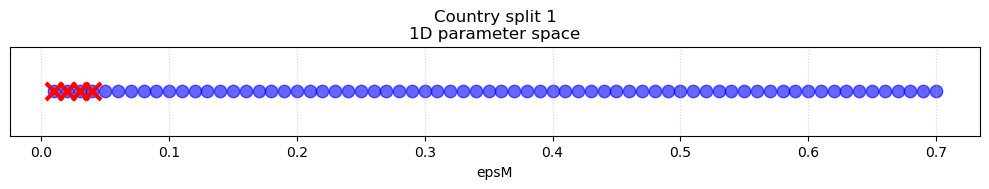


Country split 2:
  Train countries: ['UK' 'FR' 'FI' 'IE' 'BG' 'BE' 'HR' 'LU' 'MT' 'AT' 'PL' 'NL' 'CZ' 'RO']
  Test countries : ['HU' 'SK' 'SE' 'PT' 'ES' 'CY' 'SI' 'IT' 'DK' 'EL' 'D' 'DE' 'LV' 'EE' 'LT']
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


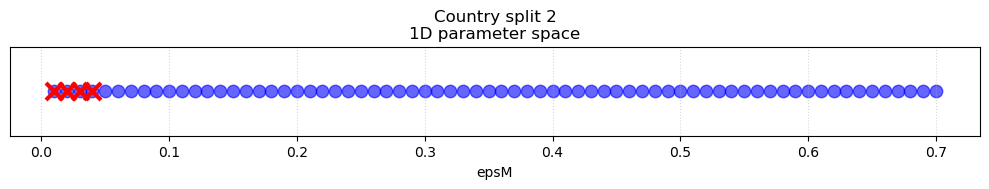


Country split 3:
  Train countries: ['BG' 'D' 'PL' 'UK' 'MT' 'CY' 'LT' 'CZ' 'EL' 'EE' 'DE' 'SI' 'SK' 'ES']
  Test countries : ['AT' 'DK' 'BE' 'FR' 'IT' 'LV' 'PT' 'IE' 'SE' 'RO' 'FI' 'HU' 'LU' 'NL'
 'HR']
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


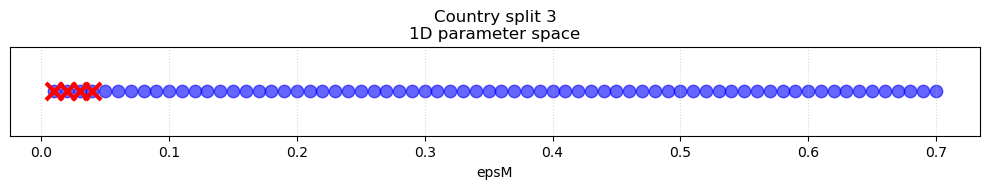


Country split 4:
  Train countries: ['UK' 'D' 'MT' 'CY' 'BE' 'HU' 'EE' 'ES' 'RO' 'PL' 'DE' 'LV' 'NL' 'SI']
  Test countries : ['IT' 'CZ' 'IE' 'LT' 'BG' 'SE' 'FI' 'EL' 'LU' 'HR' 'AT' 'FR' 'SK' 'DK'
 'PT']
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


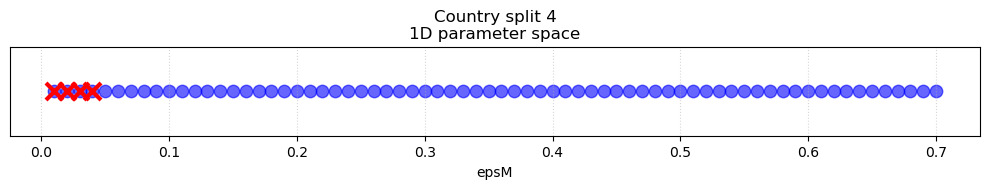


Country split 5:
  Train countries: ['IT' 'CY' 'DK' 'SE' 'AT' 'EL' 'PL' 'IE' 'SI' 'BG' 'NL' 'FI' 'LT' 'DE']
  Test countries : ['HU' 'HR' 'LU' 'MT' 'BE' 'CZ' 'UK' 'D' 'LV' 'ES' 'SK' 'PT' 'RO' 'FR' 'EE']
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


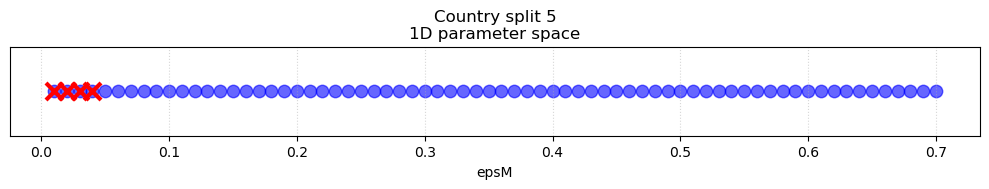


Seed split 1:
  Train seeds: [12  7 11 29 26 22  5 30  2  1 17 23 13 19 21]
  Test seeds : [20  4  9 25  6 15 27 16 24 14 18  3 10 28  8]
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


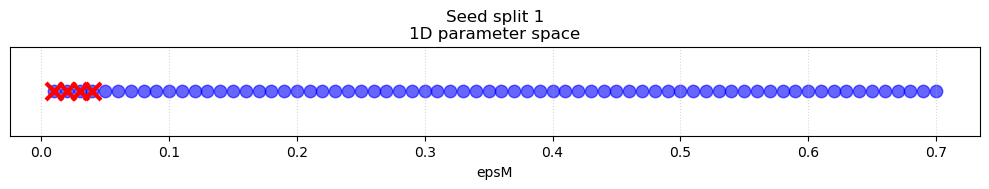


Seed split 2:
  Train seeds: [12 22 15  3 19 30 27 17 13  8 14 16  4 29  7]
  Test seeds : [ 9  2  5 24 26 11  6 23 25 18 21 20 28 10  1]
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


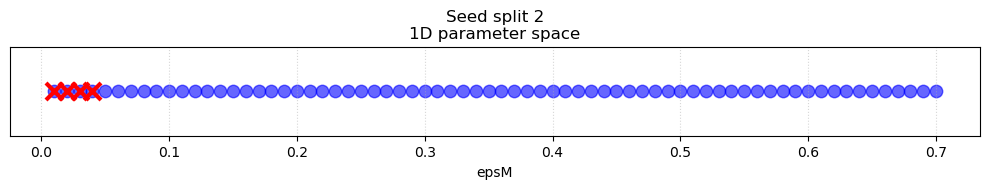


Seed split 3:
  Train seeds: [19 21 14 12 13 11  1 20  9 10 18 25 24  4  6]
  Test seeds : [26  8 30 22 23 28  5  3  2 29 15  7 17 16 27]
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


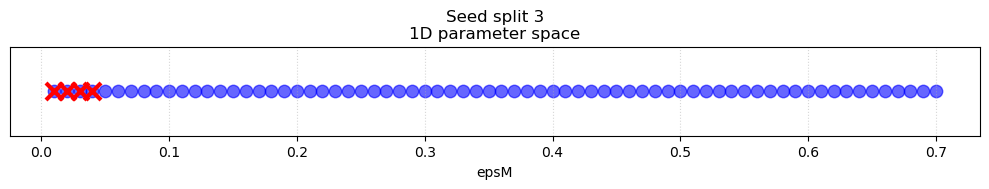


Seed split 4:
  Train seeds: [12 21 13 11  8  7 10  4 29 14 18 23 16 25 22]
  Test seeds : [20  5  1 19  3 15  9 17  2 27  6 30 24 26 28]
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


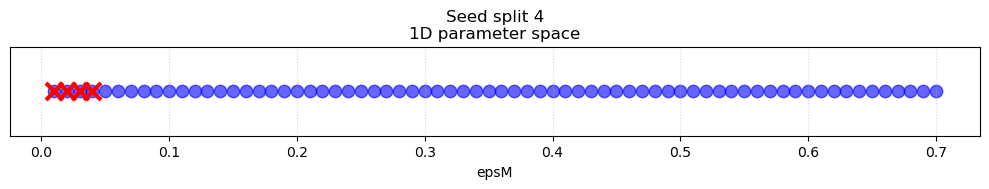


Seed split 5:
  Train seeds: [30 11  5 26 14 15 17 22 16  1  3 25  9 19 18]
  Test seeds : [ 7 27  2 13  8 20 12 21 23  4 24 28 29  6 10]
  |train_good| = 4, |test_good| = 4, |overlap| = 4
  overlap fraction (of train) = 1.000


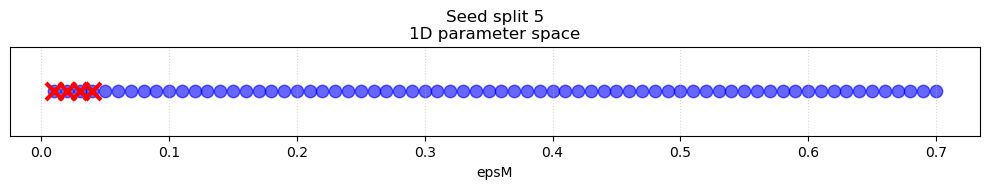


TESTING MODEL 2 – Active params: ['epsM']
Total unique parameter combinations: 70

Country split 1:
  Train countries: ['UK' 'HU' 'CY' 'RO' 'ES' 'FR' 'PT' 'BE' 'SE' 'LV' 'LU' 'IT' 'MT' 'BG']
  Test countries : ['D' 'DE' 'CZ' 'SK' 'DK' 'SI' 'FI' 'NL' 'HR' 'PL' 'EL' 'IE' 'LT' 'AT' 'EE']
  |train_good| = 4, |test_good| = 4, |overlap| = 0
  overlap fraction (of train) = 0.000


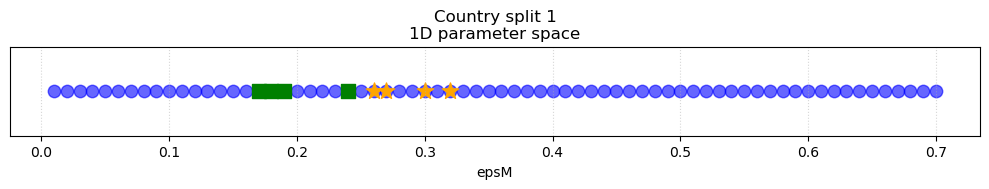


Country split 2:
  Train countries: ['UK' 'FR' 'FI' 'IE' 'BG' 'BE' 'HR' 'LU' 'MT' 'AT' 'PL' 'NL' 'CZ' 'RO']
  Test countries : ['HU' 'SK' 'SE' 'PT' 'ES' 'CY' 'SI' 'IT' 'DK' 'EL' 'D' 'DE' 'LV' 'EE' 'LT']
  |train_good| = 4, |test_good| = 4, |overlap| = 0
  overlap fraction (of train) = 0.000


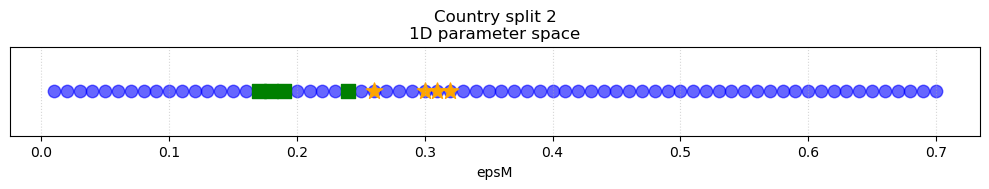


Country split 3:
  Train countries: ['BG' 'D' 'PL' 'UK' 'MT' 'CY' 'LT' 'CZ' 'EL' 'EE' 'DE' 'SI' 'SK' 'ES']
  Test countries : ['AT' 'DK' 'BE' 'FR' 'IT' 'LV' 'PT' 'IE' 'SE' 'RO' 'FI' 'HU' 'LU' 'NL'
 'HR']
  |train_good| = 4, |test_good| = 4, |overlap| = 0
  overlap fraction (of train) = 0.000


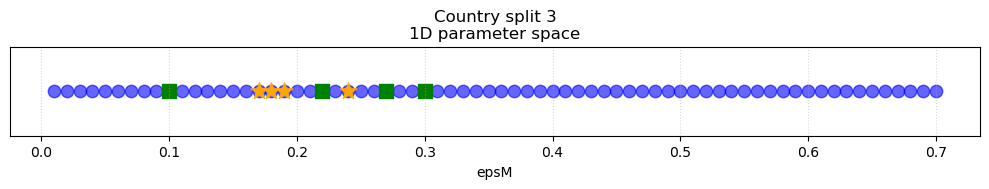


Country split 4:
  Train countries: ['UK' 'D' 'MT' 'CY' 'BE' 'HU' 'EE' 'ES' 'RO' 'PL' 'DE' 'LV' 'NL' 'SI']
  Test countries : ['IT' 'CZ' 'IE' 'LT' 'BG' 'SE' 'FI' 'EL' 'LU' 'HR' 'AT' 'FR' 'SK' 'DK'
 'PT']
  |train_good| = 4, |test_good| = 4, |overlap| = 0
  overlap fraction (of train) = 0.000


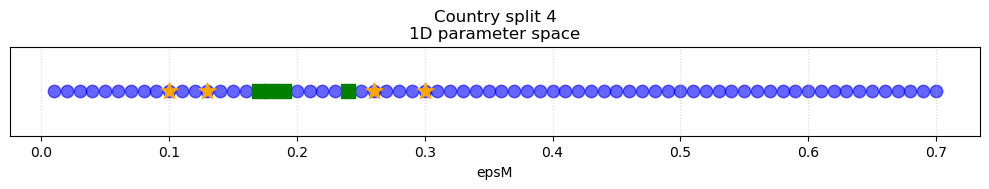


Country split 5:
  Train countries: ['IT' 'CY' 'DK' 'SE' 'AT' 'EL' 'PL' 'IE' 'SI' 'BG' 'NL' 'FI' 'LT' 'DE']
  Test countries : ['HU' 'HR' 'LU' 'MT' 'BE' 'CZ' 'UK' 'D' 'LV' 'ES' 'SK' 'PT' 'RO' 'FR' 'EE']
  |train_good| = 4, |test_good| = 4, |overlap| = 0
  overlap fraction (of train) = 0.000


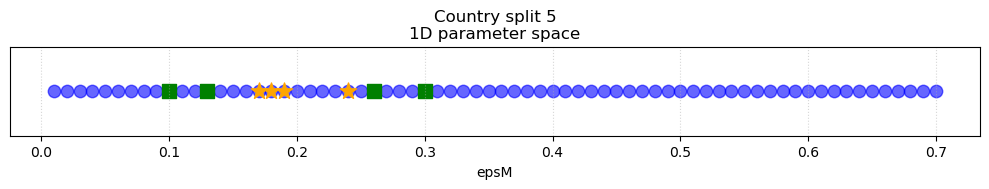


Seed split 1:
  Train seeds: [19 20 18  4 28 29 30 27 14  5 10  6  3 16 12]
  Test seeds : [ 8 11 17 15 25  9 13 26 24  2  1 21 22  7 23]
  |train_good| = 4, |test_good| = 4, |overlap| = 0
  overlap fraction (of train) = 0.000


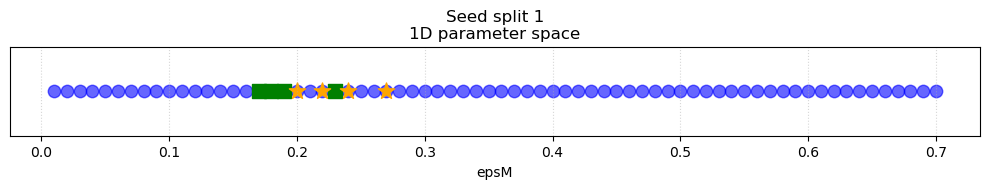


Seed split 2:
  Train seeds: [19 29  9 21 16 27 13 10  3 23  2 26 11  4 20]
  Test seeds : [17 14 30 24 28 18 25  6 15  1 12  8  7 22  5]
  |train_good| = 4, |test_good| = 4, |overlap| = 0
  overlap fraction (of train) = 0.000


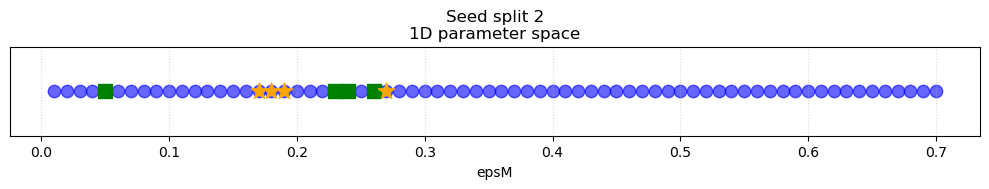


Seed split 3:
  Train seeds: [16 12  2 19  3 18  5  8 17 22  1 15 24 11 25]
  Test seeds : [28 23 27 29  6  7 30 21 14  4  9 20 10 26 13]
  |train_good| = 4, |test_good| = 4, |overlap| = 0
  overlap fraction (of train) = 0.000


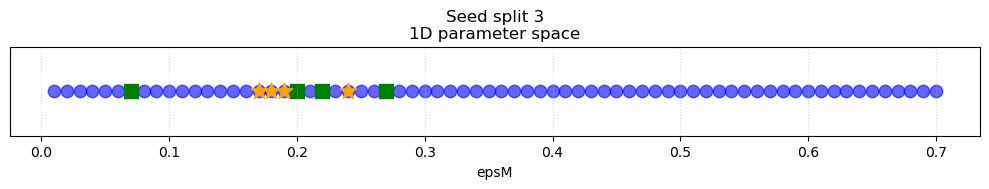


Seed split 4:
  Train seeds: [19 12  3 18 23 20 22 11  4  2  1  6 26 15 29]
  Test seeds : [ 8 30  5 16 21  9 17 10 14 13 25 27 24 28  7]
  |train_good| = 4, |test_good| = 4, |overlap| = 1
  overlap fraction (of train) = 0.250


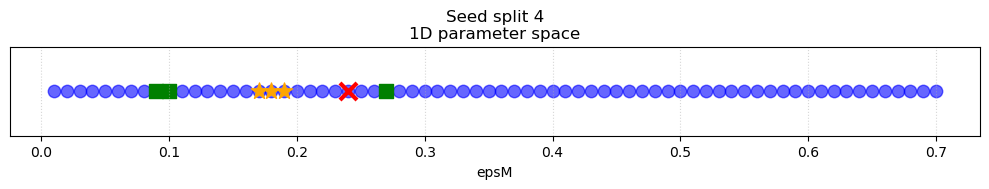


Seed split 5:
  Train seeds: [27 18 30 28  2  9 10 29 26  5 21 15 17 16  1]
  Test seeds : [20 13 14  3 23  8 19 12  6 11 24  7  4 25 22]
  |train_good| = 4, |test_good| = 4, |overlap| = 1
  overlap fraction (of train) = 0.250


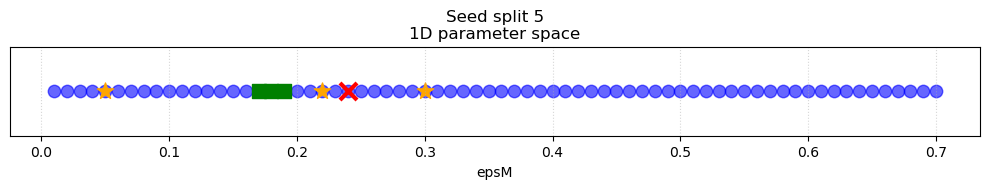


TESTING MODEL 3 – Active params: ['epsM', 'epsSD']
Total unique parameter combinations: 100

Country split 1:
  Train countries: ['UK' 'HU' 'CY' 'RO' 'ES' 'FR' 'PT' 'BE' 'SE' 'LV' 'LU' 'IT' 'MT' 'BG']
  Test countries : ['D' 'DE' 'CZ' 'SK' 'DK' 'SI' 'FI' 'NL' 'HR' 'PL' 'EL' 'IE' 'LT' 'AT' 'EE']
  |train_good| = 5, |test_good| = 5, |overlap| = 2
  overlap fraction (of train) = 0.400


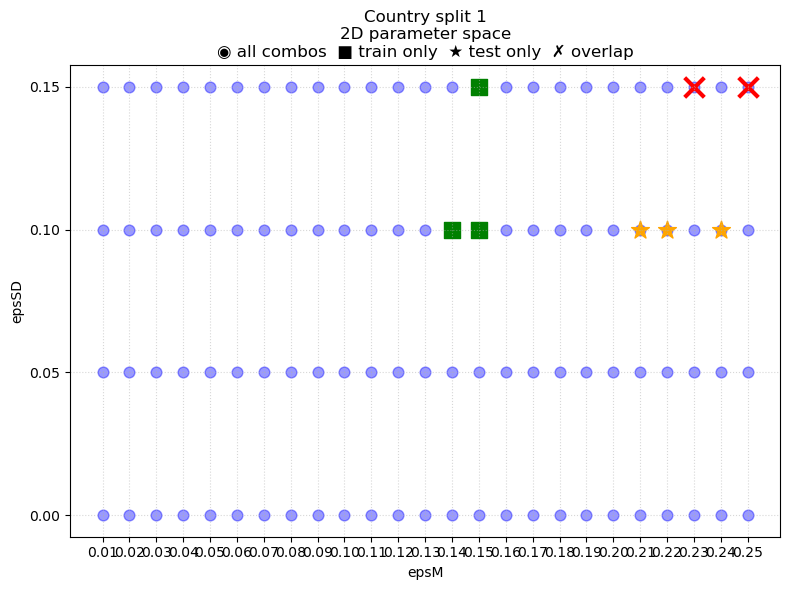


Country split 2:
  Train countries: ['UK' 'FR' 'FI' 'IE' 'BG' 'BE' 'HR' 'LU' 'MT' 'AT' 'PL' 'NL' 'CZ' 'RO']
  Test countries : ['HU' 'SK' 'SE' 'PT' 'ES' 'CY' 'SI' 'IT' 'DK' 'EL' 'D' 'DE' 'LV' 'EE' 'LT']
  |train_good| = 5, |test_good| = 5, |overlap| = 2
  overlap fraction (of train) = 0.400


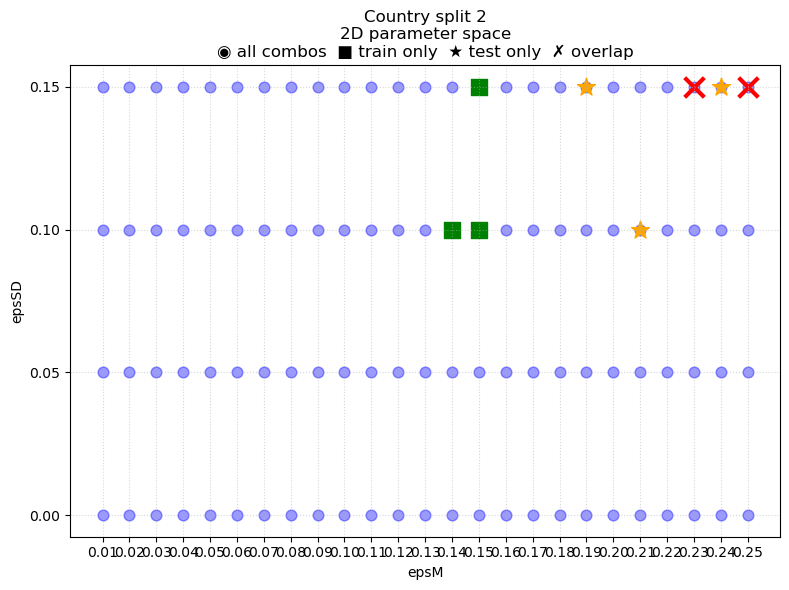


Country split 3:
  Train countries: ['BG' 'D' 'PL' 'UK' 'MT' 'CY' 'LT' 'CZ' 'EL' 'EE' 'DE' 'SI' 'SK' 'ES']
  Test countries : ['AT' 'DK' 'BE' 'FR' 'IT' 'LV' 'PT' 'IE' 'SE' 'RO' 'FI' 'HU' 'LU' 'NL'
 'HR']
  |train_good| = 5, |test_good| = 5, |overlap| = 1
  overlap fraction (of train) = 0.200


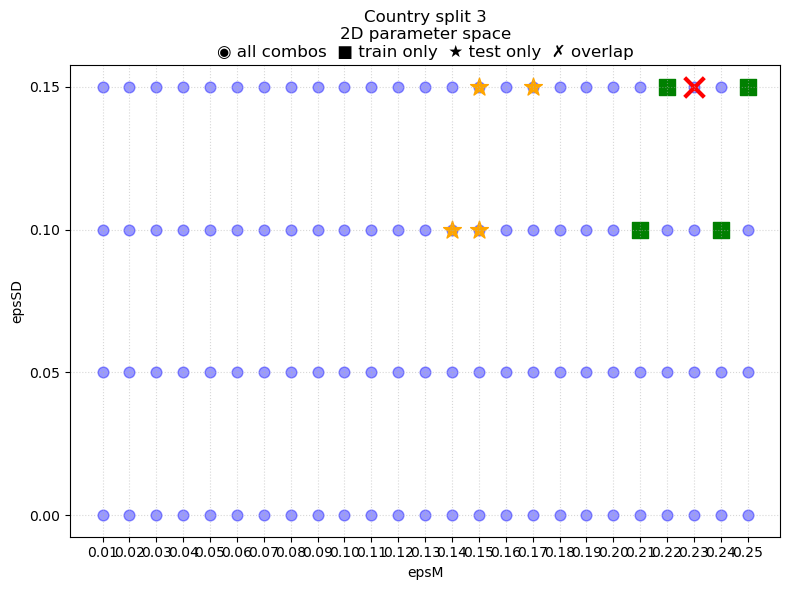


Country split 4:
  Train countries: ['UK' 'D' 'MT' 'CY' 'BE' 'HU' 'EE' 'ES' 'RO' 'PL' 'DE' 'LV' 'NL' 'SI']
  Test countries : ['IT' 'CZ' 'IE' 'LT' 'BG' 'SE' 'FI' 'EL' 'LU' 'HR' 'AT' 'FR' 'SK' 'DK'
 'PT']
  |train_good| = 5, |test_good| = 5, |overlap| = 1
  overlap fraction (of train) = 0.200


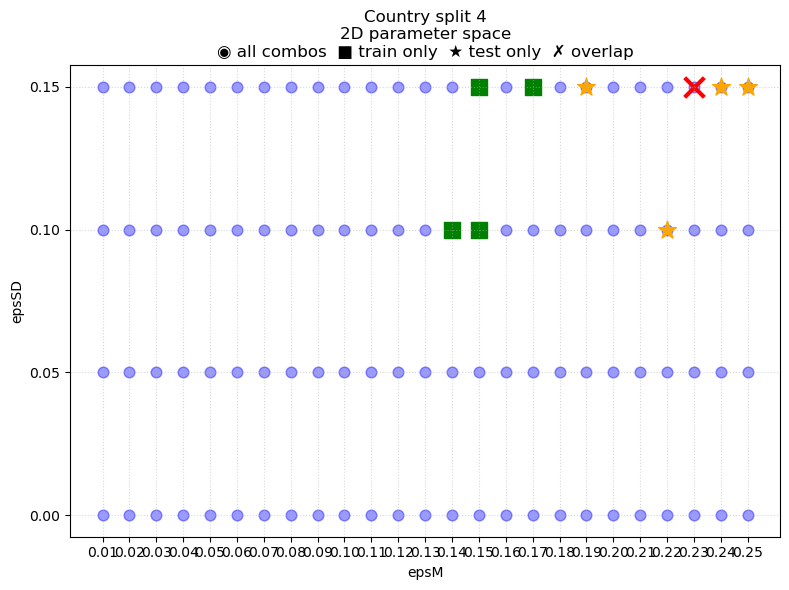


Country split 5:
  Train countries: ['IT' 'CY' 'DK' 'SE' 'AT' 'EL' 'PL' 'IE' 'SI' 'BG' 'NL' 'FI' 'LT' 'DE']
  Test countries : ['HU' 'HR' 'LU' 'MT' 'BE' 'CZ' 'UK' 'D' 'LV' 'ES' 'SK' 'PT' 'RO' 'FR' 'EE']
  |train_good| = 5, |test_good| = 5, |overlap| = 2
  overlap fraction (of train) = 0.400


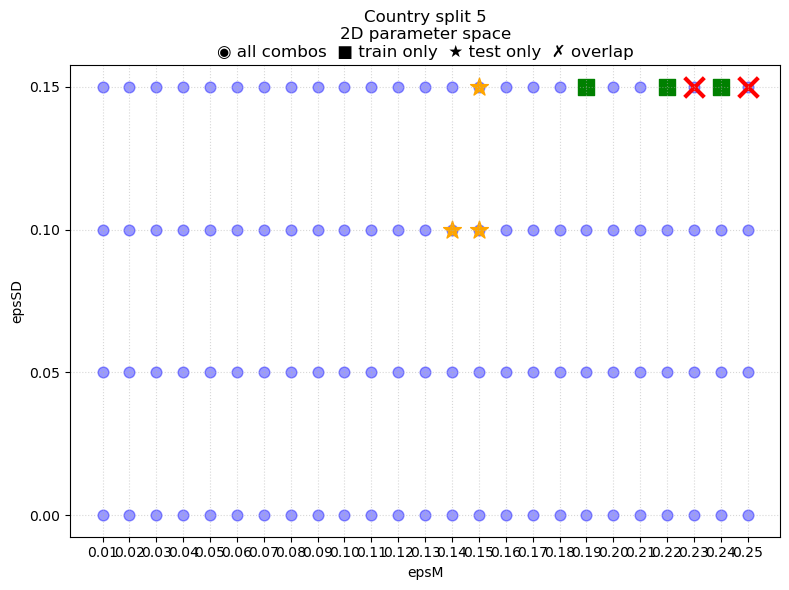


Seed split 1:
  Train seeds: [15  8 26  4 29  2 20 21 22 10  3  5  1 13 14]
  Test seeds : [ 9 11 17  7 25  6 18 19 23 30 28 16 24 12 27]
  |train_good| = 5, |test_good| = 5, |overlap| = 1
  overlap fraction (of train) = 0.200


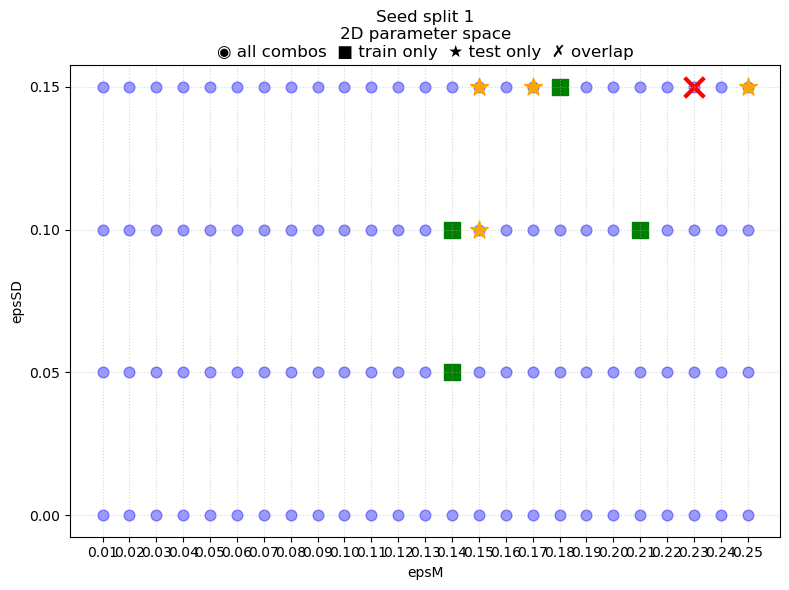


Seed split 2:
  Train seeds: [15  2  6 16 13 21 18  3  1 27 30 19 11  4  8]
  Test seeds : [17 22 20 23 29 26 25  5  7 28 14  9 12 24 10]
  |train_good| = 5, |test_good| = 5, |overlap| = 1
  overlap fraction (of train) = 0.200


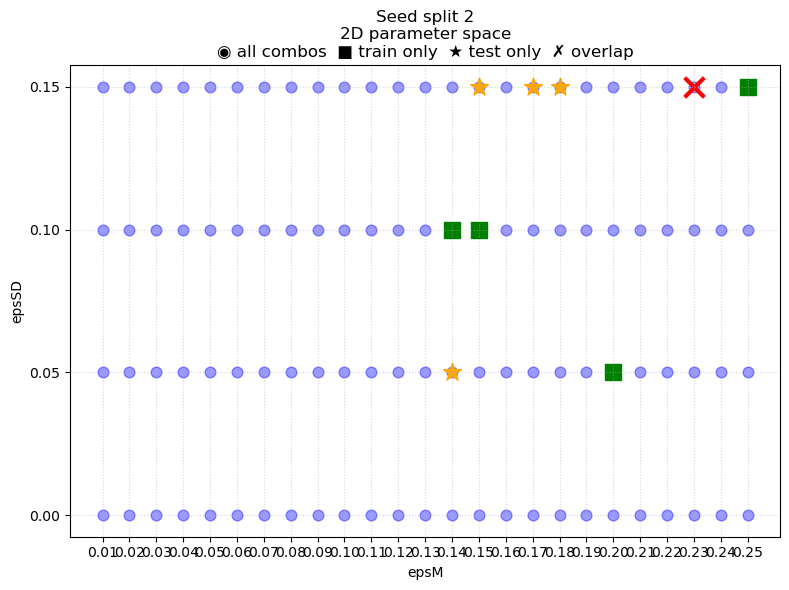


Seed split 3:
  Train seeds: [13 14 30 15  1 26 10  9 17 24 28  7 23 11 25]
  Test seeds : [29 27 21  2  5 12 20 16 22  4  6  8  3 19 18]
  |train_good| = 5, |test_good| = 5, |overlap| = 0
  overlap fraction (of train) = 0.000


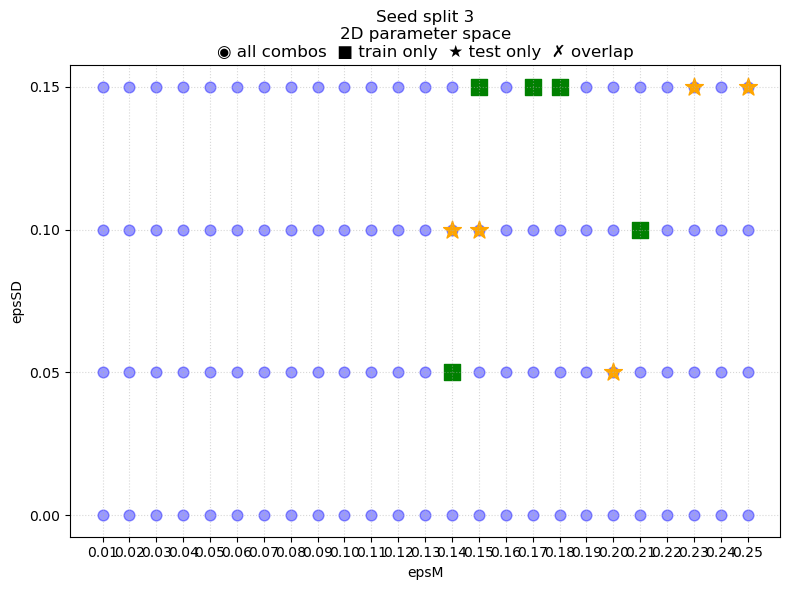


Seed split 4:
  Train seeds: [15 14  1 26 27  8 24 11  4 30 28  5 19  7  2]
  Test seeds : [ 9 20 10 13 16  6 17  3 22 18 25 21 23 29 12]
  |train_good| = 5, |test_good| = 5, |overlap| = 1
  overlap fraction (of train) = 0.200


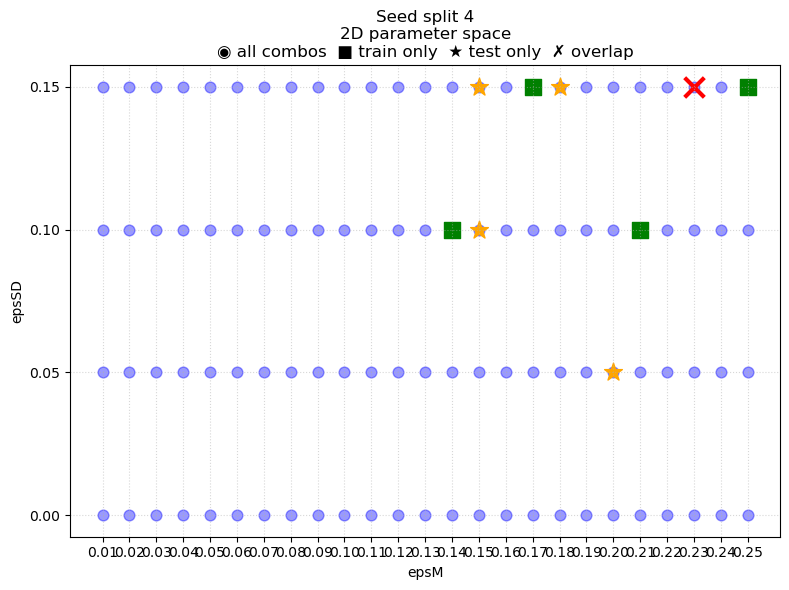


Seed split 5:
  Train seeds: [21 26 20 29 30  6  3  2 19 10 16  7 17 13 28]
  Test seeds : [ 8 18 22  1 27  9 15 14  5 11 23 12  4 25 24]
  |train_good| = 5, |test_good| = 5, |overlap| = 1
  overlap fraction (of train) = 0.200


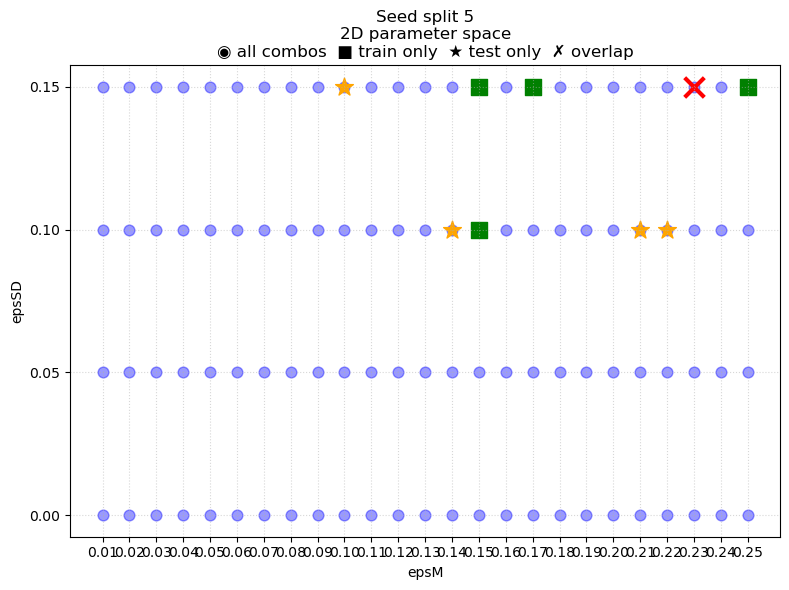

In [34]:
import matplotlib.pyplot as plt

def test_and_visualize_country_splits(df, active_params, unique_combos_df, 
                                      n_splits=5, top_percentile=5, random_seed=None):
    """
    Replicates run_country_split_overlap_v2 logic, but prints and visualizes each split.
    """
    if len(active_params) > 2:
        print(f"Active dimensions = {len(active_params)} -> cannot plot, skipping.")
        return

    countries = df['country'].unique()
    if random_seed is not None:
        np.random.seed(random_seed)   # for reproducibility of the test

    for split_idx in range(n_splits):
        # ---- identical splitting as in run_country_split_overlap_v2 ----
        np.random.shuffle(countries)
        split_point = len(countries) // 2
        train_countries = countries[:split_point]
        test_countries = countries[split_point:]

        train_data = df[df['country'].isin(train_countries)]
        test_data = df[df['country'].isin(test_countries)]

        # Use your original create_binary_success_metric (not v2) to get the sets
        train_success = create_binary_success_metric(train_data, active_params, top_percentile)
        test_success = create_binary_success_metric(test_data, active_params, top_percentile)

        train_good = set(tuple(x) for x in train_success[train_success['success'] == 1][active_params].values)
        test_good  = set(tuple(x) for x in test_success[test_success['success'] == 1][active_params].values)
        overlap = train_good & test_good

        # ---- print diagnostic info ----
        print(f"\nCountry split {split_idx+1}:")
        print(f"  Train countries: {train_countries}")
        print(f"  Test countries : {test_countries}")
        print(f"  |train_good| = {len(train_good)}, |test_good| = {len(test_good)}, |overlap| = {len(overlap)}")
        if len(train_good) > 0:
            print(f"  overlap fraction (of train) = {len(overlap)/len(train_good):.3f}")
        else:
            print("  overlap fraction = 0 (no train_good)")

        # ---- visualisation ----
        plot_param_space_with_sets(unique_combos_df, train_good, test_good, active_params,
                                   title_prefix=f"Country split {split_idx+1}")


def test_and_visualize_seed_splits(df, active_params, unique_combos_df,
                                   n_splits=5, top_percentile=5, random_seed=None):
    """
    Replicates run_seed_split_overlap logic, but prints and visualizes each split.
    """
    if len(active_params) > 2:
        print(f"Active dimensions = {len(active_params)} -> cannot plot, skipping.")
        return

    if df['RandomSeed'].nunique() < 2:
        print("Not enough RandomSeeds for seed splits.")
        return

    all_seeds = df['RandomSeed'].unique()
    if random_seed is not None:
        np.random.seed(random_seed)

    for split_idx in range(n_splits):
        np.random.shuffle(all_seeds)
        split_point = len(all_seeds) // 2
        train_seeds = all_seeds[:split_point]
        test_seeds = all_seeds[split_point:]

        train_data = df[df['RandomSeed'].isin(train_seeds)]
        test_data = df[df['RandomSeed'].isin(test_seeds)]

        train_success = create_binary_success_metric(train_data, active_params, top_percentile)
        test_success = create_binary_success_metric(test_data, active_params, top_percentile)

        train_good = set(tuple(x) for x in train_success[train_success['success'] == 1][active_params].values)
        test_good  = set(tuple(x) for x in test_success[test_success['success'] == 1][active_params].values)
        overlap = train_good & test_good

        print(f"\nSeed split {split_idx+1}:")
        print(f"  Train seeds: {train_seeds}")
        print(f"  Test seeds : {test_seeds}")
        print(f"  |train_good| = {len(train_good)}, |test_good| = {len(test_good)}, |overlap| = {len(overlap)}")
        if len(train_good) > 0:
            print(f"  overlap fraction (of train) = {len(overlap)/len(train_good):.3f}")

        plot_param_space_with_sets(unique_combos_df, train_good, test_good, active_params,
                                   title_prefix=f"Seed split {split_idx+1}")


def plot_param_space_with_sets(unique_combos_df, train_good_set, test_good_set,
                               active_params, title_prefix=""):
    """Same plotting function as before – 1D or 2D."""
    n_dims = len(active_params)
    if n_dims == 1:
        param = active_params[0]
        x_vals = sorted(unique_combos_df[param].unique())
        fig, ax = plt.subplots(figsize=(10, 2))
        for x in x_vals:
            ax.scatter(x, 0, c='blue', marker='o', s=80, alpha=0.6)
        for (x,) in train_good_set:
            if (x,) in test_good_set:
                ax.scatter(x, 0, c='red', marker='x', s=150, linewidth=3)
            else:
                ax.scatter(x, 0, c='green', marker='s', s=100)
        for (x,) in test_good_set:
            if (x,) not in train_good_set:
                ax.scatter(x, 0, c='orange', marker='*', s=150)
        ax.set_yticks([])
        ax.set_xlabel(param)
        ax.set_title(f"{title_prefix}\n1D parameter space")
        ax.grid(axis='x', linestyle=':', alpha=0.5)
    elif n_dims == 2:
        px, py = active_params[0], active_params[1]
        x_vals = sorted(unique_combos_df[px].unique())
        y_vals = sorted(unique_combos_df[py].unique())
        fig, ax = plt.subplots(figsize=(8, 6))
        for _, row in unique_combos_df.iterrows():
            ax.scatter(row[px], row[py], c='blue', marker='o', s=60, alpha=0.4)
        for tup in (train_good_set & test_good_set):
            ax.scatter(tup[0], tup[1], c='red', marker='x', s=200, linewidth=3)
        for tup in (train_good_set - test_good_set):
            ax.scatter(tup[0], tup[1], c='green', marker='s', s=120)
        for tup in (test_good_set - train_good_set):
            ax.scatter(tup[0], tup[1], c='orange', marker='*', s=180)
        ax.set_xticks(x_vals)
        ax.set_yticks(y_vals)
        ax.set_xlabel(px)
        ax.set_ylabel(py)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_title(f"{title_prefix}\n2D parameter space\n"
                     f"◉ all combos  ■ train only  ★ test only  ✗ overlap")
    else:
        print(f"Cannot plot: {n_dims} dimensions.")
        return
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------
# Run the tests for each model (using your already loaded data)
# -------------------------------------------------------------------
for stepNo in steps_to_process:
    step_idx = stepNo - 1
    df = js_fits_stepwise[step_idx].copy()
    active_params = active_params_stepwise[step_idx]
    unique_combos_df = unique_param_combos_stepwise[step_idx]   # from your earlier computation

    print(f"\n{'='*70}")
    print(f"TESTING MODEL {stepNo} – Active params: {active_params}")
    print(f"Total unique parameter combinations: {len(unique_combos_df)}")

    # Test country splits (set a fixed seed so you can compare runs)
    test_and_visualize_country_splits(df, active_params, unique_combos_df,
                                      n_splits=5, top_percentile=5, random_seed=42)

    # Test seed splits
    test_and_visualize_seed_splits(df, active_params, unique_combos_df,
                                   n_splits=5, top_percentile=5, random_seed=42)

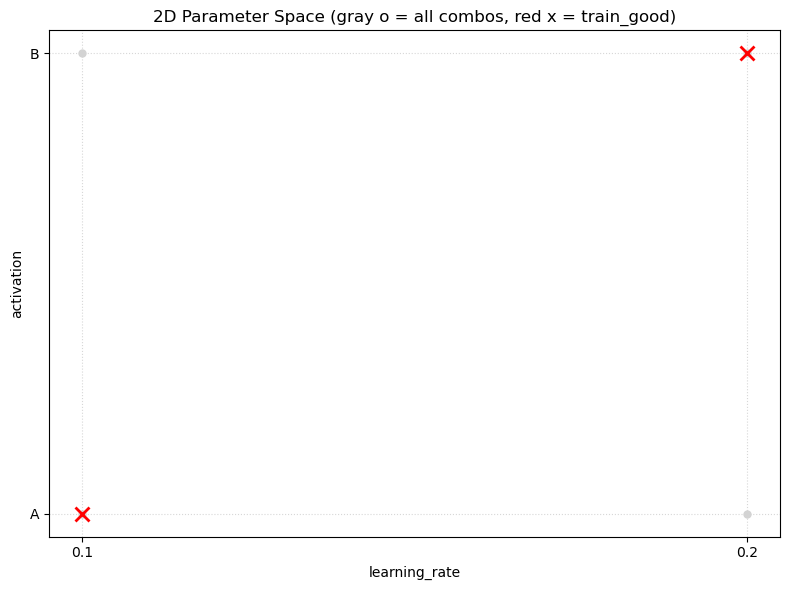

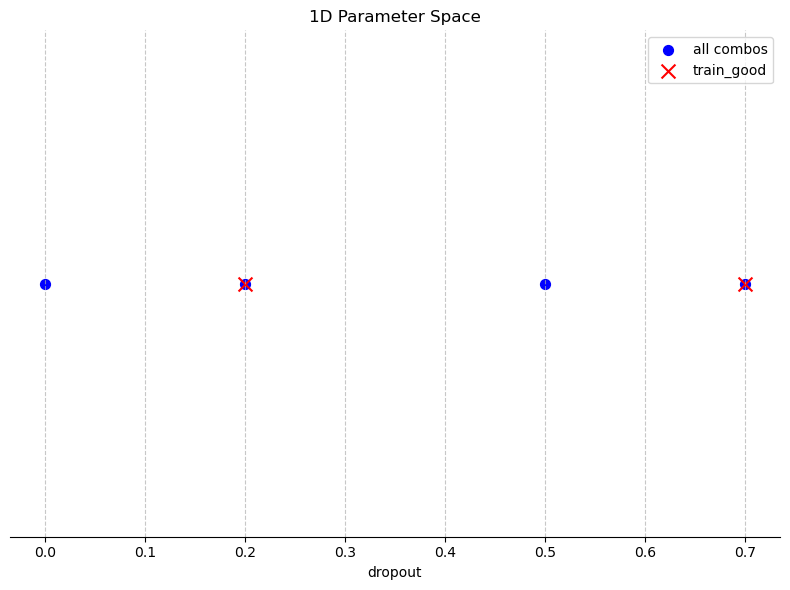

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_param_space(unique_param_combos, train_good, figsize=(8, 6)):
    """
    Visualize a parameter space grid (1D or 2D) and mark the 'good' combinations.

    Parameters
    ----------
    unique_param_combos : pd.DataFrame
        Each column is a dimension, each row is one unique combination.
        For 2D, exactly two columns; for 1D, exactly one column.
    train_good : set of tuples
        Each tuple contains values in the same order as the DataFrame columns.
        Example: for 2D with columns ['param1','param2'], train_good = {(0.1, 'A'), (0.2, 'B')}
    figsize : tuple, optional
        Size of the matplotlib figure.
    """
    dims = unique_param_combos.shape[1]
    if dims == 1:
        # ---------- 1D case ----------
        col = unique_param_combos.columns[0]
        x_vals = unique_param_combos[col].values
        # Create a set of good values for fast lookup (since tuples have one element)
        good_vals = {t[0] for t in train_good}

        fig, ax = plt.subplots(figsize=figsize)
        # Plot all points as small blue circles
        ax.scatter(x_vals, np.zeros_like(x_vals), c='blue', marker='o', s=50, label='all combos')
        # Mark good ones with red 'x'
        good_x = [v for v in x_vals if v in good_vals]
        ax.scatter(good_x, np.zeros_like(good_x), c='red', marker='x', s=100, label='train_good')
        # Add a grid and remove y-axis spines for a clean 1D look
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.grid(axis='x', linestyle='--', alpha=0.7)
        ax.set_xlabel(col)
        ax.set_title('1D Parameter Space')
        ax.legend()
        plt.tight_layout()
        plt.show()

    elif dims == 2:
        # ---------- 2D case ----------
        col0, col1 = unique_param_combos.columns[0], unique_param_combos.columns[1]
        # Get all unique values along each dimension (sorted for visual order)
        x_vals = sorted(unique_param_combos[col0].unique())
        y_vals = sorted(unique_param_combos[col1].unique())
        # Build a set for fast membership test
        good_set = set(train_good)

        fig, ax = plt.subplots(figsize=figsize)
        # Plot every combination as a small gray dot
        for _, row in unique_param_combos.iterrows():
            x = row[col0]
            y = row[col1]
            ax.plot(x, y, 'o', color='lightgray', markersize=6, markeredgecolor='none')
        # Overlay 'good' combinations with red 'x'
        for (x, y) in good_set:
            ax.plot(x, y, 'x', color='red', markersize=10, markeredgewidth=2)

        # Adjust ticks to show the actual parameter values
        ax.set_xticks(x_vals)
        ax.set_yticks(y_vals)
        ax.set_xlabel(col0)
        ax.set_ylabel(col1)
        ax.set_title('2D Parameter Space (gray o = all combos, red x = train_good)')
        # Add a light grid to emphasise the discrete cells
        ax.grid(True, linestyle=':', alpha=0.5)
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError(f"This visualizer only supports 1 or 2 dimensions. Found {dims} dimensions.")

# ========== Example usage ==========
if __name__ == "__main__":
    # ----- 2D example -----
    param1 = [0.1, 0.1, 0.2, 0.2]
    param2 = ['A', 'B', 'A', 'B']
    df_2d = pd.DataFrame({'learning_rate': param1, 'activation': param2})
    good_2d = {(0.1, 'A'), (0.2, 'B')}   # mark these two points
    plot_param_space(df_2d, good_2d)

    # ----- 1D example -----
    df_1d = pd.DataFrame({'dropout': [0.0, 0.2, 0.5, 0.7]})
    good_1d = {(0.2,), (0.7,)}          # note the comma for 1‑tuple
    plot_param_space(df_1d, good_1d)